### Convert SDO/AIA data from level 1 to level 1.5

AIA data products provides by the JSOC are level 1 data products.  
This means that the images still include the roll angle of the satellite and each channel may have a slightly different pixel scale.  
Typically, before performing any sort of data analysis on AIA images, you will want to promote your AIA data from level 1 to level 1.5.

1. Pointing correction (aiapy.calibrate.update_pointing)  
2. Image respiking (aiapy.calibrate.respike)  
3. PSF deconvolution (aiapy.psf.deconvolve)  
4. Registration (aiapy.calibrate.register)  
5. Degradation correction (aiapy.calibrate.correct_degradation)  
6. Exposure normalization

In this code, we only use method 1, 4, 5, and 6.

Reference.
https://aiapy.readthedocs.io/en/stable/preparing_data.html

In [1]:
import numpy as np
#import matplotlib.pyplot as plt
import sys, os

import astropy.units as u

import sunpy

import aiapy
from aiapy.calibrate.util import get_pointing_table
from aiapy.calibrate.util import get_correction_table

sys.path.append(os.path.abspath("../src"))
from data.ch.calibration.convert_to_level1_5 import convert_to_level1_5

__all__ = ["update_pointing"]

<class 'sunpy.map.sources.sdo.AIAMap'>


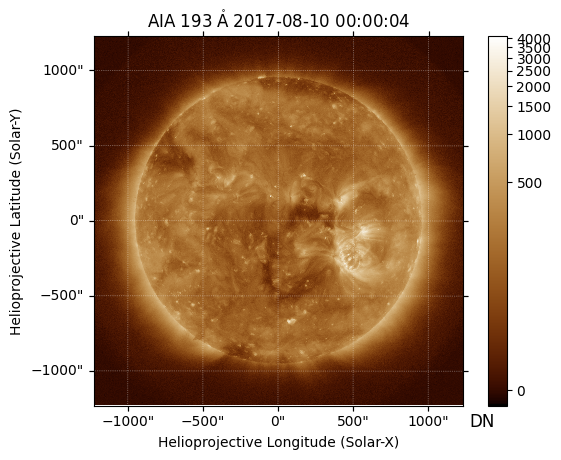

In [2]:
fits_file = r"D:\Data\AIA_level1\193\2017\aia.lev1_euv_12s.2017-08-10T000006Z.193.image_lev1.fits"
aia_map = sunpy.map.Map(fits_file)
print(type(aia_map))
aia_map.peek()

#### 1. Pointing correction

aiapy.calibrate.update_pointing(smap, *, pointing_table)

pointing_table = ``get_pointing_table``  
: This method removes any ``PCi_j`` matrix keys in the header and updates the ``CROTA2`` keyword.

In [3]:
pointing_tbl = get_pointing_table(
    # lmsal or jsoc
    "jsoc",
    time_range=(aia_map.date - 6*u.hour, aia_map.date + 6*u.hour)
)
if aia_map.meta.get("SAT_ROT") is None:
    aia_map.meta["SAT_ROT"] = 0.0

aia_map_pt = aiapy.calibrate.update_pointing(aia_map, pointing_table=pointing_tbl)

In [4]:
# To check a change.
# CRPIX: reference point
# CDELT: 
for key in ["CRPIX1","CRPIX2","CDELT1","CDELT2", "CROTA2"]:
    print(key, "before:", aia_map.meta[key], "after:", aia_map_pt.meta[key])


CRPIX1 before: 2042.85999 after: 2042.990112
CRPIX2 before: 2047.18994 after: 2047.773682
CDELT1 before: 0.600714028 after: 0.600714
CDELT2 before: 0.600714028 after: 0.600714
CROTA2 before: 0.0577115193 after: 0.0577115180218


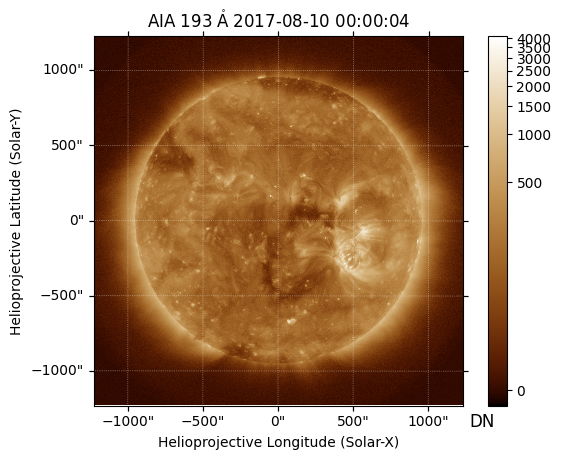

In [5]:
aia_map_pt.peek()

#### 2. Registration

In [6]:
aia_map_reg = aiapy.calibrate.register(
    aia_map_pt,
    missing=np.nan,     # extrapolation: fill with NaN
    order=3,            # interpolation: bicubic        
    method='scipy'      # Rotation function to use: scipy
)

In [7]:
# To check a change.
for key in ["CRPIX1","CRPIX2","CDELT1","CDELT2"]:
    print(key, "before:", aia_map_pt.meta[key], "after:", aia_map_reg.meta[key])

CRPIX1 before: 2042.990112 after: 2048.5
CRPIX2 before: 2047.773682 after: 2048.5
CDELT1 before: 0.600714 after: 0.6
CDELT2 before: 0.600714 after: 0.6


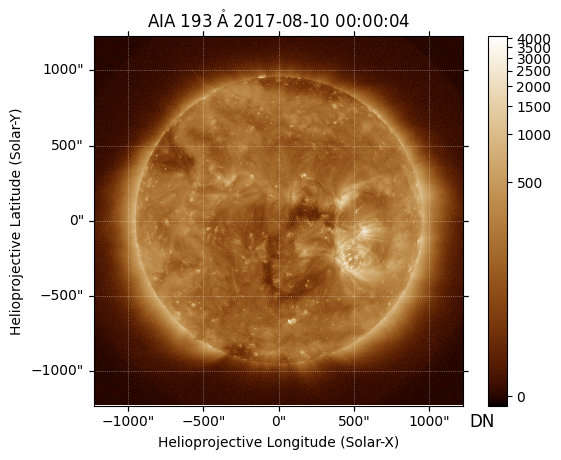

In [8]:
aia_map_reg.peek()

#### 3. Degradation correction

In [9]:
corr_tbl = get_correction_table("SSW")

aia_map_cal = aiapy.calibrate.correct_degradation(
    aia_map_reg,
    correction_table=corr_tbl
)

In [10]:
print("before:", aia_map_reg.date.isot, " after:", aia_map_cal.date.isot)

before: 2017-08-10T00:00:04.846  after: 2017-08-10T00:00:04.846


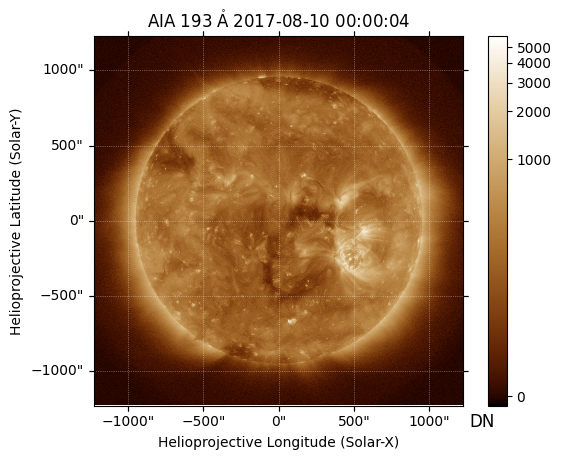

In [11]:
aia_map_cal.peek()

#### 4. Exposure normalization

In [12]:
exp_time = aia_map_cal.exposure_time

aia_map_norm = aia_map_cal / exp_time

Observatory,SDO
Instrument,AIA 2
Detector,AIA
Measurement,193.0 Angstrom
Wavelength,193.0 Angstrom
Observation Date,2017-08-10 00:00:04
Exposure Time,2.0000809999999998 s
Dimension,[4096. 4096.] pix
Coordinate System,helioprojective
Scale,[0.6 0.6] arcsec / pix
Reference Pixel,[2047.5 2047.5] pix

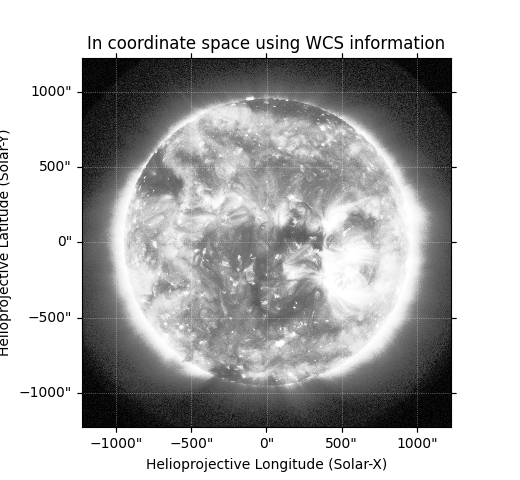
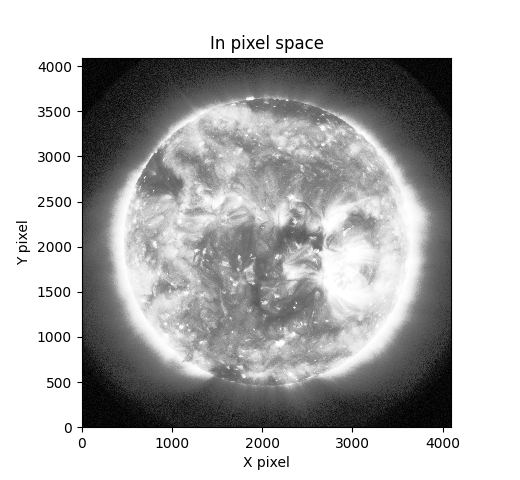
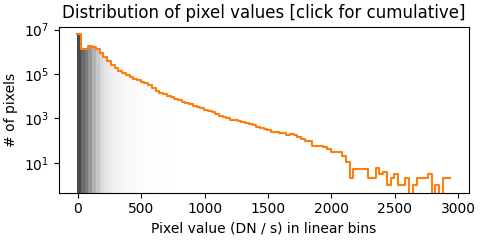
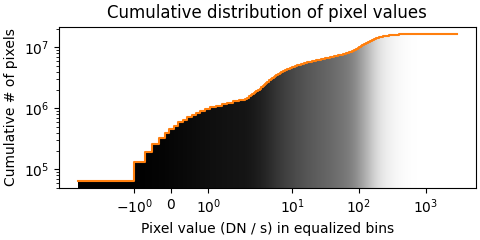

In [13]:
aia_map_norm

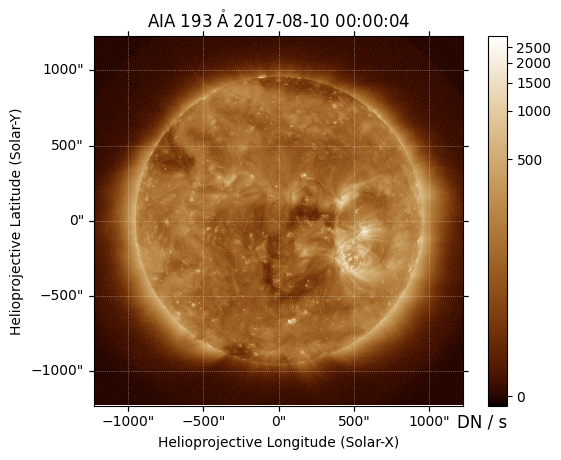

In [14]:
aia_map_norm.peek()

Observatory,SDO
Instrument,AIA 2
Detector,AIA
Measurement,193.0 Angstrom
Wavelength,193.0 Angstrom
Observation Date,2017-08-10 00:00:04
Exposure Time,2.0000809999999998 s
Dimension,[4096. 4096.] pix
Coordinate System,helioprojective
Scale,[0.6 0.6] arcsec / pix
Reference Pixel,[2047.5 2047.5] pix

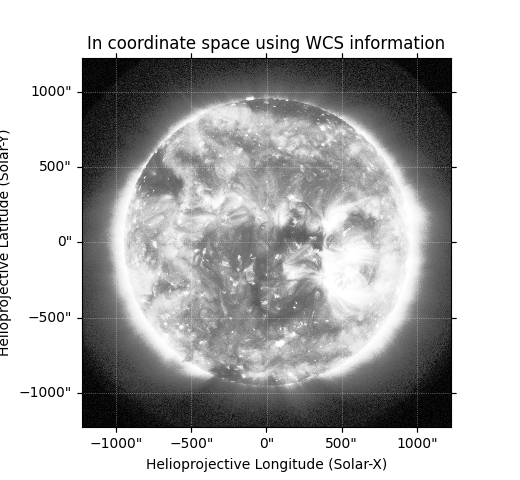
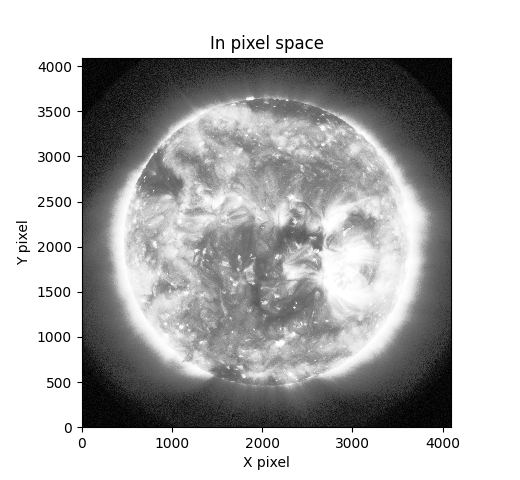
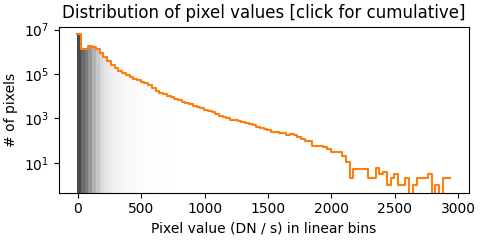
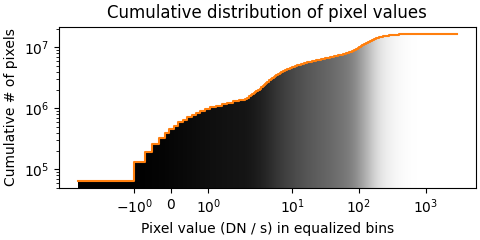

In [15]:
convert_to_level1_5(aia_map)